In [1]:
%run -i ./02_marginalization_bayes_rule_inference.ipynb
%matplotlib widget

The *expectation operator*, $E[\cdot]$, is an important tool when working with probabilities. It allows us to work out the 'average' value of a function of a random variable, $f(\mathbf{x})$, and is defined as

$$E[f(\mathbf{x})] = \int f(\mathbf{x})\,p(\mathbf{x})\,d\mathbf{x}, \tag{2.13}$$

where $p(\mathbf{x})$ is the PDF for the random variable, $\mathbf{x}$, and the integration is assumed to be over the domain of $\mathbf{x}$. This is sometimes referred to as the *law of the unconscious statistician (LOTUS)*.

In [2]:
@write_method(_ContinuousRandomEvent)
def expectation(self):
  return _ContinuousFunction(f=(lambda x: (
    np.array(self.f(x)) * self.p(x)
  )), bounds=[(-128.0, 128.0)]).integrate()

1.0000


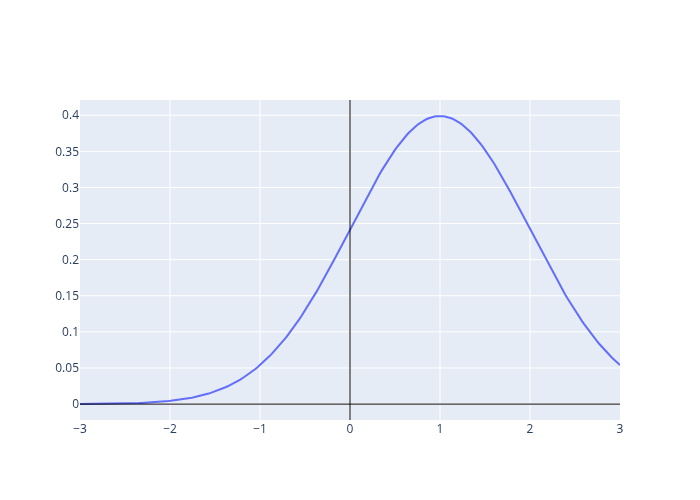

In [3]:
if __name__ == '__main__' and '__file__' not in globals():
  a = _ContinuousRandomEvent(f=_ContinuousFunction(),
                                p=_ContinuousFunction(_gaussian(1.0, 1.0)),
                                bounds=[(-128.0, 128.0)])
  print(f'{a.expectation():.4f}')
  _plot_function(a.p, (-3.0, 3.0))

For a general matrix function, $\mathbf{F}(\mathbf{x})$, the expectation is written as

$$E[\mathbf{F}(\mathbf{x})] = \int \mathbf{F}(\mathbf{x})\,p(\mathbf{x})\,d\mathbf{x}, \tag{2.14}$$

but note that we must interpret this as

$$E[\mathbf{F}(\mathbf{x})] = \big[E[f_{ij}(\mathbf{x})]\big] = \left[\int f_{ij}(\mathbf{x})\,p(\mathbf{x})\,d\mathbf{x}\right]. \tag{2.15}$$

In [4]:
@write_method(_ContinuousRandomEvent)
def expectation(self):
  return _ContinuousFunction(f=(lambda *args: (
    np.array(self.f(*args)) * self.p(*args)
  )), bounds=self.bounds).integrate()

In [5]:
from collections.abc import Callable
import numbers

@write_method(_ContinuousFunction)
def _integrate_across(self, f=None, bounds=None):
  if f is None: f = self.f
  if bounds is None: bounds = self.bounds
  
  if len(bounds) == 1:
    return self._integrate_once(f=f, bounds=bounds[0])
  else:
    def inner(x):
      return self._integrate_across(f=(lambda *rest: f(x, *rest)), 
                             bounds=bounds[1:])
    return self._integrate_once(f=inner, bounds=bounds[0])
  
@write_method(_ContinuousFunction)
def integrate(self, f=None, bounds=None):
  if f is None: f = self.f
  if bounds is None: bounds = self.bounds
  
  res = f(*([0] * len(bounds)))
  if isinstance(res, numbers.Number):
    return self._integrate_across(f, bounds)
  else:
    return np.array([self.integrate(
      (lambda *args, i=i: f(*args)[i]), bounds
    ) for i in range(len(res))])

In [6]:
import pprint

if __name__ == '__main__' and '__file__' not in globals():
  F = _ContinuousFunction(f=(lambda x, y: (
    [[x ** 0, y ** 1],
     [x ** 2, y ** 3],
     [x ** 4, y ** 5]]
  )), bounds=[(-128.0, 128.0), (-128.0, 128.0)])
  p = _ContinuousFunction(f=(lambda x, y: (
    _gaussian(3.0, 2.0)(x) * _gaussian(1.0, 1.0)(y)
  )), bounds=[(-128.0, 128.0), (-128.0, 128.0)])
  dicedo = _ContinuousRandomEvent(f=F, p=p, bounds=[(-128.0, 128.0), (-128.0, 128.0)])
  print(dicedo.f(2.5, 1.5)[0])
  print(f'{dicedo.expectation()}')
  # print(f'{dicedo.expectation():.4f}')
  

[1.0, 1.5]
[[  1.   1.]
 [ 13.   4.]
 [345.  26.]]


When working with mass distributions (a.k.a., density functions) in classical mechanics, we often keep track of only a few properties called the *moments* of mass (e.g., mass, center of mass, inertia matrix). The same is true with PDFs. The zeroth probability moment is always $1$ since this is exactly the axiom of total probability. The first probability moment is known as the *mean*, $\boldsymbol{\mu}$:

$$\boldsymbol{\mu} = E[\mathbf{x}] = \int \mathbf{x}\,p(\mathbf{x})\,d\mathbf{x}. \tag{2.16}$$

In [7]:
@write_method(_ContinuousFunction)
def expectation(self):
  res = self.f(*([0] * len(self.bounds)))
  identity = lambda *args: ([x for x in args])

  return _ContinuousFunction(f=(lambda *args: (
    np.array(identity(*args)) * self.f(*args)
  )), bounds=self.bounds).integrate()

@write_method(_ContinuousFunction)
def mean(self):
  return expectation(self)

In [8]:
if __name__ == '__main__' and '__file__' not in globals():
  F = _ContinuousFunction(f=(lambda x, y: (
    [[x ** 0, y ** 1],
     [x ** 2, y ** 3],
     [x ** 4, y ** 5]]
  )), bounds=[(-128.0, 128.0), (-128.0, 128.0)])
  p = _ContinuousFunction(f=(lambda x, y: (
    _gaussian(1.0, 2.0)(x) * _gaussian(1.0, 1.0)(y)
  )), bounds=[(-128.0, 128.0), (-128.0, 128.0)])
  dicedo = _ContinuousRandomEvent(f=F, p=p, bounds=[(-128.0, 128.0), (-128.0, 128.0)])
  print(dicedo.p.mean())

[1. 1.]


The second probability moment is known as the *covariance matrix*, $\boldsymbol{\Sigma}$:

$$\boldsymbol{\Sigma} = E\left[(\mathbf{x} - \boldsymbol{\mu})(\mathbf{x} - \boldsymbol{\mu})^T\right]. \tag{2.17}$$

In [9]:
@write_method(_ContinuousFunction)
def covariance(self):
  mean = self.mean()
  variance = _ContinuousRandomEvent(
    f=_ContinuousFunction(f=(lambda *args: (
      np.outer((np.array(args) - mean), (np.array(args) - mean))
    )), bounds=self.bounds),
    p=self.f,
    bounds=self.bounds
  )
  return variance.expectation()
  

In [10]:
if __name__ == '__main__' and '__file__' not in globals():
  F = _ContinuousFunction(f=(lambda x, y: (
    [[x ** 0, y ** 1],
     [x ** 2, y ** 3],
     [x ** 4, y ** 5]]
  )), bounds=[(-128.0, 128.0), (-128.0, 128.0)])
  p = _ContinuousFunction(f=(lambda x, y: (
    _gaussian(1.0, 2.0)(x) * _gaussian(4.0, 1.0)(y)
  )), bounds=[(-128.0, 128.0), (-128.0, 128.0)])
  dicedo = _ContinuousRandomEvent(f=F, p=p, bounds=[(-128.0, 128.0), (-128.0, 128.0)])
  print(dicedo.p.mean())
  print(dicedo.p.covariance())

[1. 4.]
[[4. 0.]
 [0. 1.]]


Finally, we are sometimes interested in the *covariance*, $\text{cov}(\cdot, \cdot)$, of two jointly distributed variables, $\mathbf{x}$ and $\mathbf{y}$, which we denote

$$\text{cov}(\mathbf{x}, \mathbf{y}) = E\left[(\mathbf{x} - E[\mathbf{x}])\,(\mathbf{y} - E[\mathbf{y}])^T\right] = E[\mathbf{x}\mathbf{y}^T] - E[\mathbf{x}]\,E[\mathbf{y}]^T. \tag{2.18}$$

Here the expectations are taken over $p(\mathbf{x}, \mathbf{y})$, the joint density. The covariance matrix just described is then a special case, $\boldsymbol{\Sigma} = \text{cov}(\mathbf{x}, \mathbf{x})$, or sometimes simply $\boldsymbol{\Sigma} = \text{cov}(\mathbf{x})$.

In [11]:
# def _covariance(X:_ContinuousRandomEvent, Y:_ContinuousRandomEvent):
#   XY_bounds = list(zip(
#     [min(b[0] for b in dims) for dims in zip((X.bounds, Y.bounds))],
#     [max(b[1] for b in dims) for dims in zip((X.bounds, Y.bounds))]
#   ))
#   XY = _ContinuousRandomEvent(
#     f=_ContinuousFunction(f=(lambda x, y: (np.outer(X.f(x), Y.f(y)))),
#                           bounds=XY_bounds),
#     p=_ContinuousFunction(f=(lambda x, y: np.outer(X.p(x), Y.p(y))),
#                           bounds=XY_bounds),
#     bounds=XY_bounds)
  
#   return XY.expectation() - np.outer(X.expectation(), Y.expectation())

In [12]:
# if __name__ == '__main__' and '__file__' not in globals():
#   aF = _ContinuousFunction(f=(lambda x, y: (
#     [[x ** 0, y ** 1],
#      [x ** 2, y ** 3],
#      [x ** 4, y ** 5]]
#   )), bounds=[(-128.0, 128.0), (-128.0, 128.0)])
#   ap = _ContinuousFunction(f=(lambda x, y: (
#     _gaussian(1.0, 2.0)(x) * _gaussian(4.0, 1.0)(y)
#   )), bounds=[(-128.0, 128.0), (-128.0, 128.0)])
#   a = _ContinuousRandomEvent(f=aF, p=ap, bounds=[(-128.0, 128.0), (-128.0, 128.0)])

#   bF = _ContinuousFunction(f=(lambda x, y: (
#     [[y ** 0, x ** 1],
#      [y ** 2, x ** 3],
#      [y ** 4, x ** 5]]
#   )), bounds=[(-128.0, 128.0), (-128.0, 128.0)])
#   bp = _ContinuousFunction(f=(lambda x, y: (
#     _gaussian(2.0, 4.0)(x) * _gaussian(-1.0, 2.0)(y)
#   )), bounds=[(-128.0, 128.0), (-128.0, 128.0)])
#   b = _ContinuousRandomEvent(f=bF, p=bp, bounds=[(-128.0, 128.0), (-128.0, 128.0)])

#   print(_covariance(a, b))

<center>

**Testing/Playground Below** 

<small><em>
(always wrap with `if __name__ == '__main__' and '__file__' not in globals():`)
</em></small>

</center>